# Target shape — `total_points` (Y)

*Read-only informative artifact. This notebook characterises the target so a
human can decide what matters. It produces no gate decisions and no
PROCEED/STOP verdict.*

## Questions a manager asks of the target

- **How many points does each position typically score in a week they play?**
  (a midfielder vs a goalkeeper — what is a "normal" haul-free return?)
- **How often does a featured player blank?** How often do they return something
  useful (4+, 6+, 8+ points)?
- **What is the ceiling?** How often does each position deliver a genuine haul
  (11+, 16+ points) that wins a gameweek?
- **How much of a player's scoring is who they are vs which week it is?**
- **What is `total_points` actually made of?** Is it fully explained by the
  other signals in this mart, or is part of it generated by something this
  dataset doesn't see?

Everything below is **season-pooled** over the study range. Week-to-week
behaviour (streaks, regression, momentum) is deferred to the `temporal/` layer.

## Setup

Load the mart, restrict to the **whole season** (GW 1 to the latest completed
GW) and to the **participation** population (`minutes > 0`), and build position
cohorts.

This is a *descriptive characterisation* notebook, so it uses the full season:
there is no reason to drop early gameweeks. (The GW-6 lower bound in the older
EDA-1 record was a *predictive-evaluation* choice — dropping early-season noise
for cleaner correlations — which does not apply here.)

The population is everyone who **actually featured**: available players with
`minutes > 0`. This is a **participation** filter (the player appeared), **not
a performance gate**. `minutes` can be NULL for some rows; `minutes > 0`
naturally excludes those (NULL comparisons are False). The 60-minute
performance-boundary question — whether `total_points` below it reflects
non-participation rather than performance — is **deferred to the `population/`
layer**, which is the layer meant to study and justify that boundary. Baking it
in here would pre-judge exactly that question.

**Double-gameweek (DGW) honesty note.** The mart carries an `is_dgw` boolean.
A DGW player-gameweek sums **two** fixtures into one `total_points` row, so
some of every distribution here — particularly the upper tail and haul mass —
is **mechanically fixture-doubling**, not single-match ceiling. These
distributions deliberately **pool SGW and DGW rows**: this notebook describes
the data AS-IS and flags the confound rather than treating it. Per-fixture
normalisation is a *treatment* (it pre-judges the dgw-vs-sgw question) and is
**deferred to the `fixture/` layer**. The next section quantifies how much
mass is affected.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.distribution import (
    compute_distribution_stats,
    compare_cohorts,
)

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

# Descriptive characterisation uses the WHOLE season: GW 1 to the latest
# completed GW. No early-GW lower bound (that was a predictive-evaluation
# choice in the older EDA-1 record, not relevant here).
STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw

# Analytical population: PARTICIPATION filter, not a performance gate.
# Available players who actually featured -> minutes > 0. `minutes` can be NULL
# for some rows; minutes > 0 naturally excludes NULLs (NULL comparisons are
# False), stated explicitly below. The 60-minute performance boundary is NOT
# imposed here -- that question is deferred to the population/ layer.
mart = _result.mart
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()

POSITIONS = ["GK", "DEF", "MID", "FWD"]
cohorts = {pos: df[df.position == pos] for pos in POSITIONS}

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.3f}".format)

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0 (participation, not a performance gate), n = {len(df):,} player-gameweeks")
for pos in POSITIONS:
    print(f"  {pos}: {len(cohorts[pos]):>6,}")


Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0 (participation, not a performance gate), n = 11,361 player-gameweeks
  GK:    757
  DEF:  3,904
  MID:  5,288
  FWD:  1,412


## DGW prevalence — magnitude of the fixture-doubling confound

**What we measure** — the count and share of featured player-gameweeks
(`minutes > 0`) that are double-gameweeks (`is_dgw == True`), overall and
broken down by position.

**What it means** — this sizes the confound the caveat above describes. It
tells the reader what fraction of the rows feeding every distribution in this
notebook carry two fixtures' worth of `total_points`. A small share means the
pooled tail is only lightly inflated; a large share means DGW mechanics drive a
meaningful slice of the upper-tail and haul mass.

**What it doesn't mean** — this is pure description of *prevalence*, not a
correction. We do **not** normalise, reweight, or exclude DGW rows; the
distributions below still pool SGW and DGW. It also says nothing about how much
a DGW inflates any single statistic — only how many rows are affected.
Per-fixture normalisation is **deferred to the `fixture/` layer**.

**Guiding question** — *How much of the featured population is double-gameweek,
and is that share even across positions?*

In [2]:
# DGW prevalence by position (descriptive only -- no normalisation, no exclusion).
_dgw = df.groupby("position")["is_dgw"].agg(n="count", dgw_rows="sum").reset_index()
_all = pd.DataFrame([{"position": "ALL", "n": len(df), "dgw_rows": int(df["is_dgw"].sum())}])
dgw_prevalence = (
    pd.concat([_dgw, _all], ignore_index=True)
    .assign(**{"dgw_%": lambda d: (d["dgw_rows"] / d["n"] * 100).round(2)})
)
display(dgw_prevalence)


,position,n,dgw_rows,dgw_%
0,DEF,3904,59,1.510
1,FWD,1412,22,1.560
2,GK,757,10,1.320
3,MID,5288,80,1.510
4,ALL,11361,171,1.510


## (a) Distribution of `total_points` by position

**What we measure** — the full univariate shape of `total_points` per position cohort via `compare_cohorts`.

Each statistic answers a different question:

- **mean, median, skew** — *What is a position worth per week?* Mean is pulled up by hauls; median is the honest midpoint. Skew says how much to trust the mean.
- **IQR, std** — *How wide is the typical band?* IQR covers the middle 50%, haul-robust. Std is haul-sensitive — overstates the typical range on a right-skewed distribution.
- **p90, p99** — *What defines the tail threshold?* The score needed to reach the top 10% / 1% of appearances at that position.
- **kurtosis** — *How extreme are tail events when they fire?* High kurtosis means hauls are outsized relative to the base distribution, not just "a good score."

**What it doesn't mean** — IQR and std describe *positional spread across the pool of players*, not individual player volatility. A specific player's consistency is a player-level question outside the scope of this notebook. The mean is not a weekly forecast.

**Guiding question** — *How many points does each position typically score in a week they play, and what is the spread?*

In [3]:
dist_by_pos = compare_cohorts(cohorts, value_col="total_points")
display(
    dist_by_pos[
        ["count", "mean", "median", "std", "p75", "p90", "p99", "max", "skew", "kurtosis"]
    ].round(2)
)


,count,mean,median,std,p75,p90,p99,max,skew,kurtosis
cohort,,,,,,,,,,
GK,757,3.390,2.000,2.750,6.000,7.000,11.000,16,1.340,1.530
DEF,3904,3.080,2.000,3.170,5.000,8.000,14.000,24,1.640,3.470
MID,5288,2.950,2.000,2.880,4.000,7.000,13.000,20,2.070,4.850
FWD,1412,2.980,2.000,3.150,4.000,8.000,13.890,19,1.980,3.680


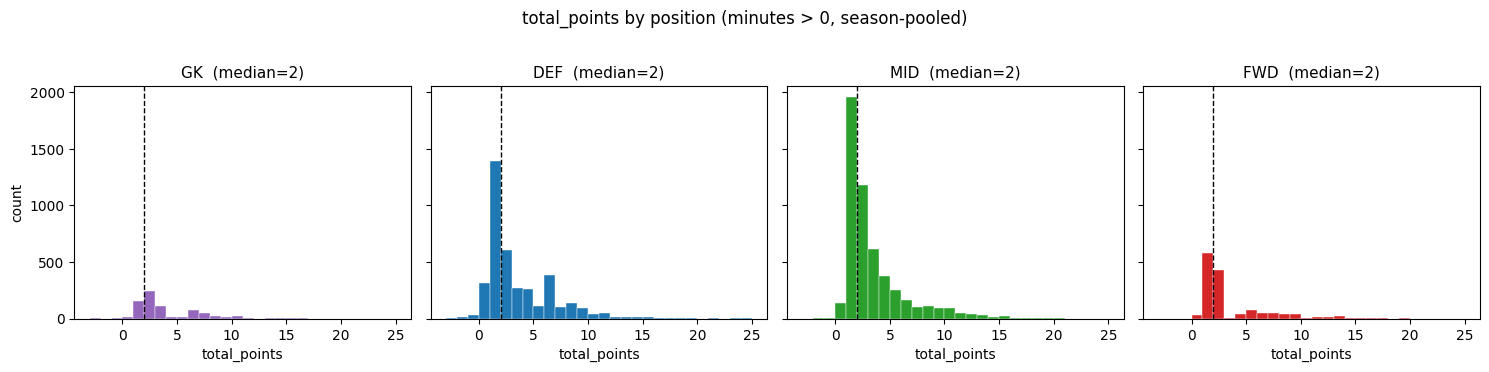

In [4]:
# Distribution shape is what a table hides here: overlaid histograms show
# where each position's mass sits and how far the right tail runs.
colours = {"GK": "#9467bd", "DEF": "#1f77b4", "MID": "#2ca02c", "FWD": "#d62728"}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
x_max = int(df["total_points"].max())
bins = range(int(df["total_points"].min()), x_max + 2)
for ax, pos in zip(axes, POSITIONS):
    s = cohorts[pos]["total_points"].dropna()
    ax.hist(s, bins=bins, color=colours[pos], edgecolor="white", linewidth=0.3)
    ax.axvline(s.median(), color="black", linestyle="--", linewidth=1.0)
    ax.set_title(f"{pos}  (median={s.median():.0f})", fontsize=11)
    ax.set_xlabel("total_points")
axes[0].set_ylabel("count")
fig.suptitle("total_points by position (minutes > 0, season-pooled)", y=1.02)
plt.tight_layout()
plt.show()


## (b) Blank and return rates by position

**What we measure** — the share of player-gameweeks that are a **strict blank** (`total_points == 0`), an **effective blank** (`total_points ≤ 2` — played but returned nothing beyond appearance points), and the share clearing return thresholds (`≥ 4`, `≥ 6`, `≥ 8`).

**What it means** — the **positional baseline** for how often a featured player returns something useful. Use median and IQR from section (a) as the distribution frame; this table pins the rates at key thresholds.

**What it doesn't mean** — these are **season-pooled** frequency counts across all players of a position, mixing reliable and volatile players. This is *not* a consistency analysis: consistency asks "does player X regularly score around their own average?" — a player-relative question that requires each player's own mean as the reference. That is a player-level question outside the scope of this notebook.

**Guiding question** — *How often does a featured player blank, and how often do they return something useful?*

In [5]:
rows = []
for pos in POSITIONS:
    y = cohorts[pos]["total_points"].dropna()
    n = len(y)
    rows.append({
        "position": pos,
        "n": n,
        "strict_blank_%": round((y == 0).mean() * 100, 1),
        "eff_blank_<=2_%": round((y <= 2).mean() * 100, 1),
        "return_4+_%": round((y >= 4).mean() * 100, 1),
        "return_6+_%": round((y >= 6).mean() * 100, 1),
        "return_8+_%": round((y >= 8).mean() * 100, 1),
    })
consistency = pd.DataFrame(rows)
display(consistency)


,position,n,strict_blank_%,eff_blank_<=2_%,return_4+_%,return_6+_%,return_8+_%
0,GK,757,2.100,55.700,29.100,25.600,8.900
1,DEF,3904,8.000,60.700,32.400,22.700,10.300
2,MID,5288,2.600,62.400,26.000,14.000,8.900
3,FWD,1412,2.300,73.800,25.800,17.400,10.700


## (c) Haul frequency by position — positional baseline

**What we measure** — the share of player-gameweeks exceeding `> 10` and `> 15` points by position.

**What it means** — the **positional baseline rate** for haul occurrence. Use it as a reference: a specific player whose haul rate is materially above this is showing a structural edge; a player near or below it is not a genuine haul threat at that threshold.

**What it doesn't mean** — this says nothing about *which* players generate the hauls. Whether hauls concentrate in a few elite players or spread broadly across the position changes the FPL calculus entirely — that is a player-level question outside the scope of this notebook. These rates pool SGW and DGW rows; the DGW-prevalence caveat from the setup section applies.

**Guiding question** — *How often does each position deliver a haul, and what rate does a specific player need to beat to justify selection?*

In [6]:
rows = []
for pos in POSITIONS:
    y = cohorts[pos]["total_points"].dropna()
    rows.append({
        "position": pos,
        "n": len(y),
        "haul_>10_%": round((y > 10).mean() * 100, 2),
        "haul_>15_%": round((y > 15).mean() * 100, 2),
    })
hauls = pd.DataFrame(rows)
display(hauls)


,position,n,haul_>10_%,haul_>15_%
0,GK,757,1.590,0.130
1,DEF,3904,3.280,0.490
2,MID,5288,3.200,0.360
3,FWD,1412,4.460,0.640


## (d) How Y is defined — the FPL scoring decomposition

**What we measure** — reconstruct `total_points` from its FPL-scoring-rule
components using the typed constants in `domain/fpl_scoring.py`: appearance
points (from `minutes`), goals (`goals_scored`, position-weighted), `assists`,
clean sheets (`clean_sheets`, position-weighted), the goals-conceded penalty
(`goals_conceded`, GK/DEF only), goalkeeper save points (`saves`),
`penalties_saved`, discipline (`yellow_cards`, `red_cards`), `bonus`, own
goals (`own_goals`), penalty misses (`penalties_missed`), and the 2025/26
**Defensive Contribution** points (2pts for a DEF reaching the CBIT threshold,
or a MID/FWD reaching the CBIRT threshold, via `defensive_contribution_points()`
applied to the gameweek's `defensive_contribution` count). The residual
(`total_points - reconstructed`) is reported per position.

**What it means** — `total_points` is not an independently-measured signal —
it is a deterministic function of these other mart signals under FPL's
published scoring rules, which is why `bonus`/`bps` (Allocation family) are
excluded from analytical use as target-leakage (`representation-rules.md` §6).
The reconstruction now matches almost exactly across **all four** positions —
including DEF and MID, which an earlier version of this notebook flagged with
a large residual concentrated at exactly +2 (the then-unmodelled 2025/26
Defensive Contribution rule). The `tackles` / `clearances_blocks_interceptions`
/ `recoveries` / `defensive_contribution` columns are now in this mart and
`domain/fpl_scoring.py`, closing that gap.

**What it doesn't mean** — this is not a redundancy finding between signals; this is Y's own definition. It
doesn't say whether Defensive Contribution should become an analytical
feature in its own right — that is a separate decision requiring its own
governance path.

**A small named DGW caveat.** `defensive_contribution_points()` is applied to
the **gameweek-summed** `defensive_contribution` count — exact for
single-fixture gameweeks. For the ~1.5% of rows that are double-gameweeks, FPL
actually awards Defensive Contribution points **per fixture, then sums**, so
`threshold(sum(fixtures))` can disagree with `sum(threshold(fixture))` by
±`DC_POINTS` when neither, or both, individual fixtures cross the threshold
but the summed count does (or vice versa). Consistent with how this notebook
names DGW prevalence and tail inflation elsewhere without normalising, this
small distortion is **named, not corrected** — it shows up below as a
non-zero residual on a handful of DGW rows.

**Guiding question** — *What is `total_points` actually made of, and where does
that definition live?*

In [7]:
from domain.fpl_scoring import (
    FULL_APPEARANCE_MIN_MINUTES, FULL_APPEARANCE_POINTS, SHORT_APPEARANCE_POINTS,
    GOAL_POINTS_GK, GOAL_POINTS_DEF, GOAL_POINTS_MID, GOAL_POINTS_FWD,
    ASSIST_POINTS,
    CLEAN_SHEET_POINTS_GK, CLEAN_SHEET_POINTS_DEF, CLEAN_SHEET_POINTS_MID, CLEAN_SHEET_POINTS_FWD,
    GOALS_CONCEDED_PER_PENALTY, GOALS_CONCEDED_PENALTY_POINTS,
    GK_SAVES_PER_POINT, GK_PENALTY_SAVE_POINTS,
    YELLOW_CARD_POINTS, RED_CARD_POINTS,
    OWN_GOAL_POINTS, PENALTY_MISS_POINTS,
    defensive_contribution_points,
)

GOAL_POINTS = {"GK": GOAL_POINTS_GK, "DEF": GOAL_POINTS_DEF, "MID": GOAL_POINTS_MID, "FWD": GOAL_POINTS_FWD}
CLEAN_SHEET_POINTS = {"GK": CLEAN_SHEET_POINTS_GK, "DEF": CLEAN_SHEET_POINTS_DEF, "MID": CLEAN_SHEET_POINTS_MID, "FWD": CLEAN_SHEET_POINTS_FWD}

position = df["position"]
appearance_pts = np.where(df["minutes"] >= FULL_APPEARANCE_MIN_MINUTES, FULL_APPEARANCE_POINTS, SHORT_APPEARANCE_POINTS)
goal_pts = df["goals_scored"] * position.map(GOAL_POINTS)
assist_pts = df["assists"] * ASSIST_POINTS
clean_sheet_pts = df["clean_sheets"] * position.map(CLEAN_SHEET_POINTS)
conceded_pts = np.where(
    position.isin(["GK", "DEF"]),
    (df["goals_conceded"] // GOALS_CONCEDED_PER_PENALTY) * GOALS_CONCEDED_PENALTY_POINTS,
    0,
)
save_pts = np.where(position == "GK", df["saves"] // GK_SAVES_PER_POINT, 0)
penalty_save_pts = df["penalties_saved"] * GK_PENALTY_SAVE_POINTS
discipline_pts = df["yellow_cards"] * YELLOW_CARD_POINTS + df["red_cards"] * RED_CARD_POINTS
own_goal_pts = df["own_goals"] * OWN_GOAL_POINTS
penalty_miss_pts = df["penalties_missed"] * PENALTY_MISS_POINTS

# Defensive Contribution (2025/26): 2pts if the gameweek-summed
# `defensive_contribution` count meets the position's CBIT/CBIRT threshold.
# Exact for SGW rows; see the DGW caveat in the markdown above for the small
# population of double-gameweek rows where this can disagree with FPL's
# per-fixture-then-summed points.
dc_pts = np.array([
    defensive_contribution_points(pos, dc)
    for pos, dc in zip(position, df["defensive_contribution"])
])

reconstructed = (
    appearance_pts + goal_pts + assist_pts + clean_sheet_pts
    + conceded_pts + save_pts + penalty_save_pts + discipline_pts + df["bonus"]
    + own_goal_pts + penalty_miss_pts + dc_pts
)
residual = df["total_points"] - reconstructed

rows = []
for pos in POSITIONS:
    r = residual[position == pos]
    rows.append({
        "position": pos,
        "n": len(r),
        "exact_match_%": round((r == 0).mean() * 100, 2),
        "residual_+2_%": round((r == 2).mean() * 100, 2),
        "mean_abs_residual": round(r.abs().mean(), 3),
    })
recon_summary = pd.DataFrame(rows)
display(recon_summary)


,position,n,exact_match_%,residual_+2_%,mean_abs_residual
0,GK,757,98.680,0.530,0.021
1,DEF,3904,99.130,0.410,0.017
2,MID,5288,99.090,0.280,0.012
3,FWD,1412,99.080,0.570,0.015


## Player-level structure — see also

The positional picture above prompts player-level questions that this notebook
doesn't answer:

- **Variance decomposition** (is Y's spread driven by who's playing or which
  week it is?) — `structure/target_variance.ipynb`.
- **Haul concentration** and **consistency** (do hauls concentrate in a few
  players? how variable is a "typical" player's reliability?) —

## What the target looks like

Plain-language summary of the descriptive picture (not a verdict):

- **Median is 2 across all positions** — the honest positional base rate. Half of all
  featured appearances return 2 or fewer points. The mean (~3) is higher because it is
  pulled up by rare hauls; median is the more trustworthy summary.

- **Most appearances are effective blanks** — Y≤2 captures the majority of featured
  player-GWs across all positions. A score of 2 means the player showed up and contributed
  nothing beyond appearance points. Strict zero blanks (Y=0) are rarer but effective
  blanks are the norm, not the exception.

- **All positions are right-skewed** — rare hauls pull the mean above the median.
  MID has the highest skew (2.07) and kurtosis (4.85) — the fattest tail of any
  position. When reading any player's season average, ask how much of it is
  one or two haul weeks inflating the number.

- **GK/DEF have a wider scoring band (IQR=4) than MID/FWD (IQR=3)** — the middle
  50% of defensive appearances are spread across a wider range. Why is not answerable
  from this notebook.

- **Hauls are rare** — fewer than 10% of appearances exceed 10 pts (p90) across any
  position. p99 is in the 11-14 pt range. These are tail events, not typical returns.
  Whether hauls concentrate in a few elite players or spread broadly is a player-level
  question outside the scope of this notebook.

- **DGW prevalence is ~1.5%** — a small share of featured player-GWs. The mechanical
  tail inflation from DGW rows is real but limited in magnitude.

- **Y is now fully explained by this mart's signals, with a small named DGW
  caveat** — reconstructing `total_points` from `domain/fpl_scoring.py`, now
  including the 2025/26 Defensive Contribution rule, matches exactly for
  98.7-99.1% of player-gameweeks across **all four positions** (previously
  GK/FWD only, at ~97-98%, with DEF/MID residuals concentrated at exactly +2
  from the then-unmodelled Defensive Contribution rule). The remaining <1%
  residual is concentrated on double-gameweek rows, where applying the
  Defensive Contribution threshold to the gameweek-summed
  `defensive_contribution` count can disagree with FPL's true
  per-fixture-then-summed points by ±2 points — a small, named DGW
  distortion, not a missing component.

All figures are **whole-season**, season-pooled, over the **participation** population
(`minutes > 0`, not a performance gate). The 60-minute boundary is left to the
`population/` layer. Week-to-week behaviour is left to the `temporal/` layer.
Player-level structure beyond variance decomposition is left to the `temporal/` and `families/` layers. Variance decomposition is in `structure/target_variance.ipynb`.
